In [9]:
import json, pickle, gc, librosa
from sklearn.model_selection import GroupShuffleSplit

SR, MAX_SEC, SEED = 16000, 6, 42          # 6 s to match your earlier runs
CLASSES = ["teens", "twenties", "thirties", "fourties"]
l2i = {c: i for i, c in enumerate(CLASSES)}
dev_ = "cuda" if torch.cuda.is_available() else "cpu"
WORK = "/kaggle/working"

df = df[df.age_group.isin(CLASSES)].reset_index(drop=True).copy()
df["label"] = df.age_group.map(l2i)
df["is_female"] = df.gender.str.startswith("female")

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
_, test_idx = next(gss.split(df, groups=df.client_id))
df["split"] = "dev"
df.loc[test_idx, "split"] = "test"
dev = df[df.split == "dev"]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1875, random_state=SEED)   # 15% of all speakers
tr_idx, va_idx = next(gss2.split(dev, groups=dev.client_id))
df.loc[dev.index[tr_idx], "split"] = "train"
df.loc[dev.index[va_idx], "split"] = "val"
df.to_csv(f"{WORK}/ru_age_splits.csv", index=False)

for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    assert not set(df[df.split == a].client_id) & set(df[df.split == b].client_id)
print(df.groupby("split").agg(clips=("path", "size"), speakers=("client_id", "nunique")))
print(pd.crosstab(df.split, df.age_group))

       clips  speakers
split                 
test    1089       237
train   3456       769
val      788       178
age_group  fourties  teens  thirties  twenties
split                                         
test            103    143       306       537
train           356    495       955      1650
val              68    119       242       359


In [10]:
CACHE = f"{WORK}/audio_cache.pkl"
if os.path.exists(CACHE):
    audio = pickle.load(open(CACHE, "rb"))
else:
    audio, bad = {}, []
    for i, p in enumerate(df.fullpath):
        try:
            y, _ = librosa.load(p, sr=SR, mono=True, duration=MAX_SEC)
            audio[p] = y.astype(np.float16)
        except Exception:
            bad.append(p)
        if i % 500 == 0:
            print(i, "/", len(df))
    pickle.dump(audio, open(CACHE, "wb"))
    print("failed:", len(bad))

df = df[df.fullpath.isin(audio)].reset_index(drop=True)
print(len(audio), "clips cached |", len(df), "rows")

0 / 5333
500 / 5333
1000 / 5333
1500 / 5333
2000 / 5333
2500 / 5333
3000 / 5333
3500 / 5333
4000 / 5333
4500 / 5333
5000 / 5333
failed: 0
5333 clips cached | 5333 rows


In [11]:
from transformers import AutoFeatureExtractor, AutoModel

def extract_layers(model_name):
    fe = AutoFeatureExtractor.from_pretrained(model_name)
    enc = AutoModel.from_pretrained(model_name).to(dev_).eval()
    feats = [[] for _ in range(enc.config.num_hidden_layers + 1)]
    with torch.no_grad():
        for i, p in enumerate(df.fullpath):
            x = fe(audio[p].astype(np.float32), sampling_rate=SR,
                   return_tensors="pt").input_values.to(dev_)
            hs = enc(x, output_hidden_states=True).hidden_states     # (layers+1) x (1, T, D)
            for l, h in enumerate(hs):
                feats[l].append(h[0].mean(0).float().cpu().numpy())
            if i % 1000 == 0:
                print(i)
    X = np.stack([np.stack(f) for f in feats])                        # (layers, clips, D)
    out = f"layers_{model_name.split('/')[-1]}.npy"
    np.save(out, X)
    print("saved", out, X.shape)
    del enc; gc.collect(); torch.cuda.empty_cache()
    return X

X_w2v2 = extract_layers("facebook/wav2vec2-base")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0
1000
2000
3000
4000
5000
saved layers_wav2vec2-base.npy (13, 5333, 768)


age    layer  0: 0.301 ± 0.012
age    layer  1: 0.309 ± 0.028
age    layer  2: 0.327 ± 0.015
age    layer  3: 0.332 ± 0.032
age    layer  4: 0.332 ± 0.026
age    layer  5: 0.333 ± 0.019
age    layer  6: 0.321 ± 0.017
age    layer  7: 0.323 ± 0.019
age    layer  8: 0.308 ± 0.020
age    layer  9: 0.312 ± 0.016
age    layer 10: 0.322 ± 0.012
age    layer 11: 0.295 ± 0.018
age    layer 12: 0.303 ± 0.004
gender layer  0: 0.939 ± 0.015
gender layer  1: 0.955 ± 0.013
gender layer  2: 0.959 ± 0.013
gender layer  3: 0.966 ± 0.013
gender layer  4: 0.966 ± 0.011
gender layer  5: 0.956 ± 0.011
gender layer  6: 0.954 ± 0.015
gender layer  7: 0.952 ± 0.013
gender layer  8: 0.955 ± 0.009
gender layer  9: 0.954 ± 0.012
gender layer 10: 0.960 ± 0.017
gender layer 11: 0.952 ± 0.010
gender layer 12: 0.941 ± 0.010


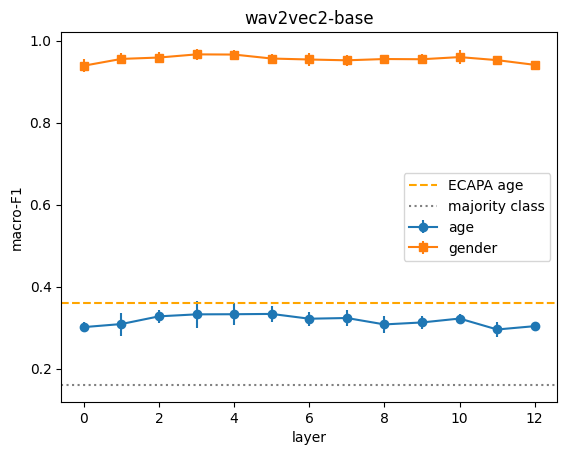

best age layer: 5 [0.33318775 0.01859545]


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

dev_mask = (df.split != "test").values
y_age = df.label.values[dev_mask]
y_gen = df.is_female.values[dev_mask]
g = df.client_id.values[dev_mask]

def make_clf():
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=3000, class_weight="balanced"))

def probe(X_layers, y, groups, name):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    res = []
    for l in range(X_layers.shape[0]):
        s = cross_val_score(make_clf(), X_layers[l], y, groups=groups, cv=cv, scoring="f1_macro")
        res.append((s.mean(), s.std()))
        print(f"{name:6s} layer {l:2d}: {s.mean():.3f} ± {s.std():.3f}")
    return np.array(res)

def plot_probe(age_res, gen_res, title):
    plt.errorbar(range(len(age_res)), age_res[:, 0], age_res[:, 1], marker="o", label="age")
    plt.errorbar(range(len(gen_res)), gen_res[:, 0], gen_res[:, 1], marker="s", label="gender")
    plt.axhline(0.36, ls="--", c="orange", label="ECAPA age")
    plt.axhline(0.16, ls=":", c="gray", label="majority class")
    plt.xlabel("layer"); plt.ylabel("macro-F1"); plt.title(title); plt.legend(); plt.show()

age_w2v2 = probe(X_w2v2[:, dev_mask], y_age, g, "age")
gen_w2v2 = probe(X_w2v2[:, dev_mask], y_gen, g, "gender")
plot_probe(age_w2v2, gen_w2v2, "wav2vec2-base")
best_layer = int(age_w2v2[:, 0].argmax())
print("best age layer:", best_layer, age_w2v2[best_layer])

In [13]:
def stratified_report(X, y, groups, is_female):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    pred = cross_val_predict(make_clf(), X, y, groups=groups, cv=cv)
    for name, m in [("male", ~is_female), ("female", is_female)]:
        print(f"\n== {name}: {m.sum()} clips | macro-F1 = "
              f"{f1_score(y[m], pred[m], average='macro'):.3f}")
        print(classification_report(y[m], pred[m], labels=range(len(CLASSES)),
                                    target_names=CLASSES, digits=3, zero_division=0))

stratified_report(X_w2v2[best_layer][dev_mask], y_age, g, y_gen)


== male: 3205 clips | macro-F1 = 0.333
              precision    recall  f1-score   support

       teens      0.266     0.293     0.279       447
    twenties      0.541     0.458     0.496      1498
    thirties      0.346     0.373     0.359       947
    fourties      0.173     0.233     0.198       313

    accuracy                          0.388      3205
   macro avg      0.331     0.339     0.333      3205
weighted avg      0.409     0.388     0.396      3205


== female: 1039 clips | macro-F1 = 0.334
              precision    recall  f1-score   support

       teens      0.297     0.419     0.347       167
    twenties      0.579     0.476     0.522       511
    thirties      0.270     0.284     0.277       250
    fourties      0.183     0.198     0.190       111

    accuracy                          0.391      1039
   macro avg      0.332     0.344     0.334      1039
weighted avg      0.417     0.391     0.400      1039



In [19]:
from torch import nn
from torch.utils.data import Dataset
from transformers import (AutoModelForAudioClassification, TrainingArguments,
                          Trainer, EarlyStoppingCallback)
from sklearn.utils.class_weight import compute_class_weight

class ClipDataset(Dataset):
    def __init__(self, frame):
        self.paths, self.labels = frame.fullpath.tolist(), frame.label.tolist()
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        return {"audio": audio[self.paths[i]].astype(np.float32), "labels": self.labels[i]}

def make_collate(fe):
    def collate(batch):
        out = fe([b["audio"] for b in batch], sampling_rate=SR, padding=True, return_tensors="pt")
        out["labels"] = torch.tensor([b["labels"] for b in batch])
        return out
    return collate

def metrics(ep):
    return {"f1_macro": f1_score(ep.label_ids, ep.predictions.argmax(-1), average="macro")}

class WeightedTrainer(Trainer):
    def __init__(self, *a, class_weights=None, **k):
        super().__init__(*a, **k)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        logits = model(**inputs).logits
        loss = nn.functional.cross_entropy(logits, labels,
                                           weight=self.class_weights.to(logits.device))
        return (loss, {"logits": logits}) if return_outputs else loss

def run_finetune(model_name, classes, tag, freeze_encoder, lr, epochs,
                 init_from=None, precision="fp32", patience=3):
    sub = df[df.age_group.isin(classes)].copy()
    c2i = {c: i for i, c in enumerate(classes)}
    sub["label"] = sub.age_group.map(c2i)
    tr, va, te = (sub[sub.split == s] for s in ["train", "val", "test"])
    w = torch.tensor(compute_class_weight("balanced", classes=np.arange(len(classes)),
                                          y=tr.label.values), dtype=torch.float32)
    print("class weights:", dict(zip(classes, w.numpy().round(2))))
    print(f"uniform-predictor loss = ln({len(classes)}) = {np.log(len(classes)):.3f}")

    fe = AutoFeatureExtractor.from_pretrained(model_name)
    model = init_from or AutoModelForAudioClassification.from_pretrained(
        model_name, num_labels=len(classes), label2id=c2i,
        id2label={i: c for c, i in c2i.items()}, use_weighted_layer_sum=True)
    for p in model.base_model.parameters():          # transformer on/off
        p.requires_grad = not freeze_encoder
    model.freeze_feature_encoder()                   # CNN always frozen

    steps_per_epoch = int(np.ceil(len(tr) / (8 * 2)))       # batch 8 x accumulation 2
    warmup = int(0.1 * steps_per_epoch * epochs)

    args = TrainingArguments(
        output_dir=f"{WORK}/ft_{tag}",
        per_device_train_batch_size=8, gradient_accumulation_steps=2,
        per_device_eval_batch_size=8,
        learning_rate=lr, num_train_epochs=epochs, warmup_steps=warmup, max_grad_norm=1.0,
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
        logging_steps=25, fp16=(precision == "fp16"), bf16=(precision == "bf16"),
        remove_unused_columns=False, report_to="none", seed=SEED)
    trainer = WeightedTrainer(
        model=model, args=args, class_weights=w,
        train_dataset=ClipDataset(tr), eval_dataset=ClipDataset(va),
        data_collator=make_collate(fe), compute_metrics=metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)])
    trainer.train()

    p = trainer.predict(ClipDataset(te))
    pred = p.predictions.argmax(-1)
    print("\n== TEST ==")
    print(classification_report(p.label_ids, pred, labels=range(len(classes)),
                                target_names=classes, digits=3, zero_division=0))
    res = {"tag": tag, "model": model_name, "classes": classes,
           "freeze_encoder": freeze_encoder, "lr": lr, "epochs": epochs,
           "precision": precision, "best_val_f1": trainer.state.best_metric,
           "test_f1_macro": float(f1_score(p.label_ids, pred, average="macro")),
           "n_train_clips": len(tr), "n_val_clips": len(va), "n_test_clips": len(te)}
    json.dump(res, open(f"results_{tag}.json", "w"), indent=2)
    print(res)
    return trainer

In [20]:
t_head = run_finetune(MODEL, CLASSES, "w2v2_age_head", freeze_encoder=True, lr=1e-3, epochs=8)

class weights: {'teens': np.float32(1.75), 'twenties': np.float32(0.52), 'thirties': np.float32(0.9), 'fourties': np.float32(2.43)}
uniform-predictor loss = ln(4) = 1.386


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
layer_weights                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro
1,2.651671,1.337935,0.277661
2,2.438039,1.335508,0.326446
3,2.356634,1.343837,0.332046
4,1.912564,1.334506,0.323317
5,2.031949,1.332628,0.367015
6,1.862111,1.378225,0.343186
7,1.679344,1.344105,0.364063
8,1.802610,1.337627,0.374642


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


== TEST ==
              precision    recall  f1-score   support

       teens      0.283     0.329     0.304       143
    twenties      0.589     0.469     0.522       537
    thirties      0.358     0.379     0.368       306
    fourties      0.275     0.456     0.343       103

    accuracy                          0.424      1089
   macro avg      0.376     0.408     0.384      1089
weighted avg      0.454     0.424     0.433      1089

{'tag': 'w2v2_age_head', 'model': 'facebook/wav2vec2-base', 'classes': ['teens', 'twenties', 'thirties', 'fourties'], 'freeze_encoder': True, 'lr': 0.001, 'epochs': 8, 'precision': 'fp32', 'best_val_f1': 0.3746416585323884, 'test_f1_macro': 0.3844516435429599, 'n_train_clips': 3456, 'n_val_clips': 788, 'n_test_clips': 1089}


In [21]:
prec = "bf16" if torch.cuda.get_device_capability()[0] >= 8 else "fp32"
t_full = run_finetune(MODEL, CLASSES, "w2v2_age_full", freeze_encoder=False, lr=2e-5,
                      epochs=15, init_from=t_head.model, precision=prec, patience=4)
del t_head; gc.collect(); torch.cuda.empty_cache()

class weights: {'teens': np.float32(1.75), 'twenties': np.float32(0.52), 'thirties': np.float32(0.9), 'fourties': np.float32(2.43)}
uniform-predictor loss = ln(4) = 1.386


Epoch,Training Loss,Validation Loss,F1 Macro
1,1.944876,1.390448,0.365895
2,1.694010,1.555980,0.319716
3,1.328909,1.569602,0.381046
4,0.824933,1.924939,0.361382
5,0.583031,2.154747,0.359387
6,0.469968,2.421431,0.371289
7,0.185881,3.039146,0.333348


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


== TEST ==
              precision    recall  f1-score   support

       teens      0.322     0.343     0.332       143
    twenties      0.578     0.497     0.535       537
    thirties      0.360     0.408     0.383       306
    fourties      0.273     0.340     0.303       103

    accuracy                          0.437      1089
   macro avg      0.383     0.397     0.388      1089
weighted avg      0.454     0.437     0.443      1089

{'tag': 'w2v2_age_full', 'model': 'facebook/wav2vec2-base', 'classes': ['teens', 'twenties', 'thirties', 'fourties'], 'freeze_encoder': False, 'lr': 2e-05, 'epochs': 15, 'precision': 'fp32', 'best_val_f1': 0.38104614705998474, 'test_f1_macro': 0.3881541548580249, 'n_train_clips': 3456, 'n_val_clips': 788, 'n_test_clips': 1089}


In [22]:
t_bin = run_finetune(MODEL, ["teens", "fourties"], "w2v2_bin_head", freeze_encoder=True, lr=1e-3, epochs=8)
t_bin_full = run_finetune(MODEL, ["teens", "fourties"], "w2v2_bin_full", freeze_encoder=False,
                          lr=2e-5, epochs=15, init_from=t_bin.model, precision=prec)
del t_bin, t_bin_full; gc.collect(); torch.cuda.empty_cache()

class weights: {'teens': np.float32(0.86), 'fourties': np.float32(1.2)}
uniform-predictor loss = ln(2) = 0.693


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
layer_weights                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro
1,1.328735,0.631805,0.655875
2,1.171652,0.574919,0.691660
3,0.980415,0.562775,0.702988
4,0.906067,0.622436,0.688466
5,0.771289,0.574735,0.705669
6,0.707060,0.610958,0.709090
7,0.650018,0.577436,0.714196
8,0.628134,0.578708,0.721726


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


== TEST ==
              precision    recall  f1-score   support

       teens      0.845     0.762     0.801       143
    fourties      0.709     0.806     0.755       103

    accuracy                          0.780       246
   macro avg      0.777     0.784     0.778       246
weighted avg      0.788     0.780     0.782       246

{'tag': 'w2v2_bin_full', 'model': 'facebook/wav2vec2-base', 'classes': ['teens', 'fourties'], 'freeze_encoder': False, 'lr': 2e-05, 'epochs': 15, 'precision': 'fp32', 'best_val_f1': 0.8007792286853559, 'test_f1_macro': 0.7780080213903744, 'n_train_clips': 851, 'n_val_clips': 187, 'n_test_clips': 246}


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

0


model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

1000
2000
3000
4000
5000
saved layers_wavlm-base-plus.npy (13, 5333, 768)
age    layer  0: 0.290 ± 0.012
age    layer  1: 0.306 ± 0.029
age    layer  2: 0.326 ± 0.033
age    layer  3: 0.337 ± 0.023
age    layer  4: 0.349 ± 0.024
age    layer  5: 0.345 ± 0.019
age    layer  6: 0.363 ± 0.017
age    layer  7: 0.341 ± 0.019
age    layer  8: 0.318 ± 0.011
age    layer  9: 0.307 ± 0.020
age    layer 10: 0.307 ± 0.015
age    layer 11: 0.321 ± 0.025
age    layer 12: 0.329 ± 0.026
gender layer  0: 0.946 ± 0.012
gender layer  1: 0.959 ± 0.007
gender layer  2: 0.961 ± 0.011
gender layer  3: 0.961 ± 0.012
gender layer  4: 0.961 ± 0.020
gender layer  5: 0.959 ± 0.021
gender layer  6: 0.954 ± 0.020
gender layer  7: 0.949 ± 0.020
gender layer  8: 0.947 ± 0.019
gender layer  9: 0.939 ± 0.014
gender layer 10: 0.938 ± 0.018
gender layer 11: 0.945 ± 0.021
gender layer 12: 0.939 ± 0.015


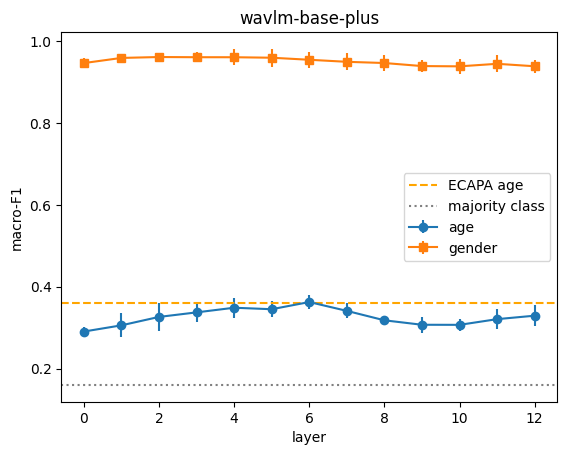


== male: 3205 clips | macro-F1 = 0.374
              precision    recall  f1-score   support

       teens      0.310     0.367     0.336       447
    twenties      0.557     0.470     0.510      1498
    thirties      0.382     0.405     0.393       947
    fourties      0.229     0.297     0.258       313

    accuracy                          0.420      3205
   macro avg      0.369     0.385     0.374      3205
weighted avg      0.439     0.420     0.427      3205


== female: 1039 clips | macro-F1 = 0.331
              precision    recall  f1-score   support

       teens      0.244     0.395     0.302       167
    twenties      0.542     0.440     0.486       511
    thirties      0.313     0.312     0.313       250
    fourties      0.229     0.216     0.222       111

    accuracy                          0.378      1039
   macro avg      0.332     0.341     0.331      1039
weighted avg      0.406     0.378     0.387      1039

class weights: {'teens': np.float32(1.75), 'twen

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
projector.weight  | MISSING | 
projector.bias    | MISSING | 
classifier.bias   | MISSING | 
layer_weights     | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


Epoch,Training Loss,Validation Loss


RuntimeError: The size of tensor a (12) must match the size of tensor b (13) at non-singleton dimension 1

In [23]:
X_wavlm = extract_layers("microsoft/wavlm-base-plus")
age_wavlm = probe(X_wavlm[:, dev_mask], y_age, g, "age")
gen_wavlm = probe(X_wavlm[:, dev_mask], y_gen, g, "gender")
plot_probe(age_wavlm, gen_wavlm, "wavlm-base-plus")
stratified_report(X_wavlm[int(age_wavlm[:, 0].argmax())][dev_mask], y_age, g, y_gen)

t_wlm = run_finetune("microsoft/wavlm-base-plus", CLASSES, "wavlm_age_head", freeze_encoder=True, lr=1e-3, epochs=8)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  290MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

0
1000
2000
3000
4000
5000
age    layer  0: 0.294 ± 0.013
age    layer  1: 0.303 ± 0.026
age    layer  2: 0.323 ± 0.019
age    layer  3: 0.339 ± 0.032
age    layer  4: 0.338 ± 0.029
age    layer  5: 0.317 ± 0.022
age    layer  6: 0.324 ± 0.008
gender layer  0: 0.937 ± 0.017
gender layer  1: 0.954 ± 0.014
gender layer  2: 0.960 ± 0.015
gender layer  3: 0.956 ± 0.014
gender layer  4: 0.957 ± 0.016
gender layer  5: 0.954 ± 0.015
gender layer  6: 0.948 ± 0.018


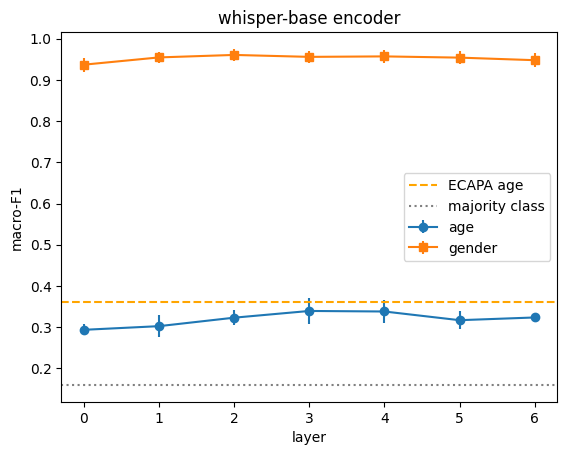

In [24]:
from transformers import WhisperFeatureExtractor, WhisperModel

def extract_whisper(name="openai/whisper-base"):
    fe = WhisperFeatureExtractor.from_pretrained(name)
    enc = WhisperModel.from_pretrained(name).encoder.to(dev_).eval()
    feats = [[] for _ in range(enc.config.encoder_layers + 1)]
    with torch.no_grad():
        for i, p in enumerate(df.fullpath):
            a = audio[p].astype(np.float32)
            x = fe(a, sampling_rate=SR, return_tensors="pt").input_features.to(dev_)
            n = max(1, int(np.ceil(len(a) / SR * 50)))
            hs = enc(x, output_hidden_states=True).hidden_states
            for l, h in enumerate(hs):
                feats[l].append(h[0, :n].mean(0).float().cpu().numpy())
            if i % 1000 == 0:
                print(i)
    X = np.stack([np.stack(f) for f in feats])
    np.save(f"layers_{name.split('/')[-1]}.npy", X)
    del enc; gc.collect(); torch.cuda.empty_cache()
    return X

X_whisper = extract_whisper("openai/whisper-base")
age_whisper = probe(X_whisper[:, dev_mask], y_age, g, "age")
gen_whisper = probe(X_whisper[:, dev_mask], y_gen, g, "gender")
plot_probe(age_whisper, gen_whisper, "whisper-base encoder")

In [25]:
summary = {
    "probe_best_layer_age_f1": {
        "wav2vec2-base": [int(age_w2v2[:, 0].argmax()), float(age_w2v2[:, 0].max())],
        "wavlm-base-plus": [int(age_wavlm[:, 0].argmax()), float(age_wavlm[:, 0].max())],
        "whisper-base": [int(age_whisper[:, 0].argmax()), float(age_whisper[:, 0].max())],
    },
    "finetune_runs": [json.load(open(f)) for f in sorted(glob.glob("results_*.json"))],
}
json.dump(summary, open("v2_summary.json", "w"), indent=2)
print(json.dumps(summary, indent=2))

{
  "probe_best_layer_age_f1": {
    "wav2vec2-base": [
      5,
      0.3331877467167737
    ],
    "wavlm-base-plus": [
      6,
      0.3625130369085068
    ],
    "whisper-base": [
      3,
      0.3393853094093992
    ]
  },
  "finetune_runs": [
    {
      "tag": "w2v2_age_full",
      "model": "facebook/wav2vec2-base",
      "classes": [
        "teens",
        "twenties",
        "thirties",
        "fourties"
      ],
      "freeze_encoder": false,
      "lr": 2e-05,
      "epochs": 15,
      "precision": "fp32",
      "best_val_f1": 0.38104614705998474,
      "test_f1_macro": 0.3881541548580249,
      "n_train_clips": 3456,
      "n_val_clips": 788,
      "n_test_clips": 1089
    },
    {
      "tag": "w2v2_age_head",
      "model": "facebook/wav2vec2-base",
      "classes": [
        "teens",
        "twenties",
        "thirties",
        "fourties"
      ],
      "freeze_encoder": true,
      "lr": 0.001,
      "epochs": 8,
      "precision": "fp32",
      "best_val_f1": 